# Kapitel 3 Regression

## Uppgift 1
Regressionsproblem används när målet är att förutsäga ett numeriskt, kontinuerligt värde istället för en kategori.
Exempel: Förutsäga bostadspriser, företags framtida försäljningsvolymer eller bilars bränsleförbrukning.

## Uppgift 2
- MSE (Mean Squared Error): Medelvärdet av de kvadrerade felen. Det straffar stora fel extra hårt eftersom felen kvadreras.
- RMSE (Root Mean Squared Error): Roten ur MSE. Det visar felet i samma enhet som målvariabeln och är därför lätt att tolka.
- MAE (Mean Absolute Error): Medelvärdet av de absoluta felen utan kvadrering. Det påverkas mindre av extremvärden.

## Uppgift 3
Nej, det spelar ingen roll för rangordningen av modellerna om man använder RMSE eller MSE. Eftersom RMSE bara är roten ur MSE ändras inte ordningen mellan modellerna; den modell som har lägst MSE har alltid också lägst RMSE.

## Uppgift 4
Gradient descent är en optimeringsmetod som stegvis justerar modellens parametrar (vikter) i den riktning där felet minskar mest, tills modellen når det minsta möjliga felet.

## Uppgift 5
Bias-variance trade-off handlar om balansen mellan underanpassning och överanpassning:
- Bias: Felet som uppstår när modellen är för enkel och missar mönster i datan (underanpassning).
- Varians: Felet som uppstår när modellen är för känslig och anpassar sig efter bruset i träningsdatan (överanpassning).
Mer komplexa modeller är inte alltid bättre eftersom hög varians gör att de presterar sämre på ny data.

## Uppgift 6
Översikt av vanliga regressionsmodeller:
a) Linjär regression: Anpassar en rät linje efter datapunkterna genom att minimera kvadrerade fel.
b) Ridge regression: Linjär regression med ett straff för stora koefficienter (L2) för att motverka överanpassning.
c) Lasso regression: Linjär regression med ett straff (L1) som kan nollställa oviktiga variabler och ge automatisk variabelselektion.
d) Elastic net: Kombinerar straffen från både Ridge och Lasso.
e) Support vector machines (SVR): Försöker passa in så många datapunkter som möjligt inom en viss marginal runt linjen.
f) Beslutsträd: Delar upp datan i mindre delar med hjälp av if/else-villkor.
g) Ensemble learning: Kombinerar flera modeller för att få ett stabilare resultat, t.ex. genom röstning eller medelvärde.
h) Random forest: En samling av många slumpade beslutsträd som tränas tillsammans för att minska överanpassning.

## Uppgift 7
- White box-modeller: Modeller som är enkla och lätta att förstå och tolka, t.ex. linjär regression och enkla beslutsträd.
- Black box-modeller: Komplexa modeller där det är svårt att se exakt hur och varför en förutsägelse gjordes, t.ex. djupa neurala nätverk och Random Forest.

## Uppgift 8
- Bagging: Modeller tränas på slumpade delmängder av datan med återläggning (samma datapunkt kan väljas flera gånger).
- Pasting: Modeller tränas på slumpade delmängder utan återläggning.

## Uppgift 9
Figur 3.1 visar att när modellen görs mer komplex minskar träningsfelet hela tiden, men testfelet minskar bara till en viss gräns. Blir modellen för komplex börjar testfelet öka igen på grund av överanpassning.

## Uppgift 10
Figur 3.13 visar hur modeller anpassar sig till data: rak linje (underanpassning), lagom kurva (bra passning) och en vilt svängande linje (överanpassning). Figur 3.14 visar motsvarande inlärningskurvor som bekräftar att en överanpassad modell har ett stort gap mellan tränings- och valideringsfel.

## Uppgift 11
Determinationskoefficienten (R2) mäter hur stor del av variationen i målvariabeln som modellen förklarar:
- R2 = 1.0 betyder perfekt modell som förklarar all variation.
- R2 = 0.0 betyder att modellen inte är bättre än att alltid gissa medelvärdet.
- R2 < 0.0 betyder att modellen presterar sämre än det enkla medelvärdet.

## Uppgift 13
EDA på personaldata i hr_employee_data.xlsx.

     Emp_Id  satisfaction_level  ...  Department  salary
0  IND02438                0.38  ...       sales     low
1  IND28133                0.80  ...       sales  medium
2  IND07164                0.11  ...       sales  medium
3  IND30478                0.72  ...       sales     low
4  IND24003                0.37  ...       sales     low

[5 rows x 11 columns]
<class 'pandas.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Emp_Id                 14999 non-null  str    
 1   satisfaction_level     14999 non-null  float64
 2   last_evaluation        14999 non-null  float64
 3   number_project         14999 non-null  int64  
 4   average_montly_hours   14999 non-null  int64  
 5   time_spend_company     14999 non-null  int64  
 6   Work_accident          14999 non-null  int64  
 7   left                   14999 non-null  int64  
 8   promotion_la

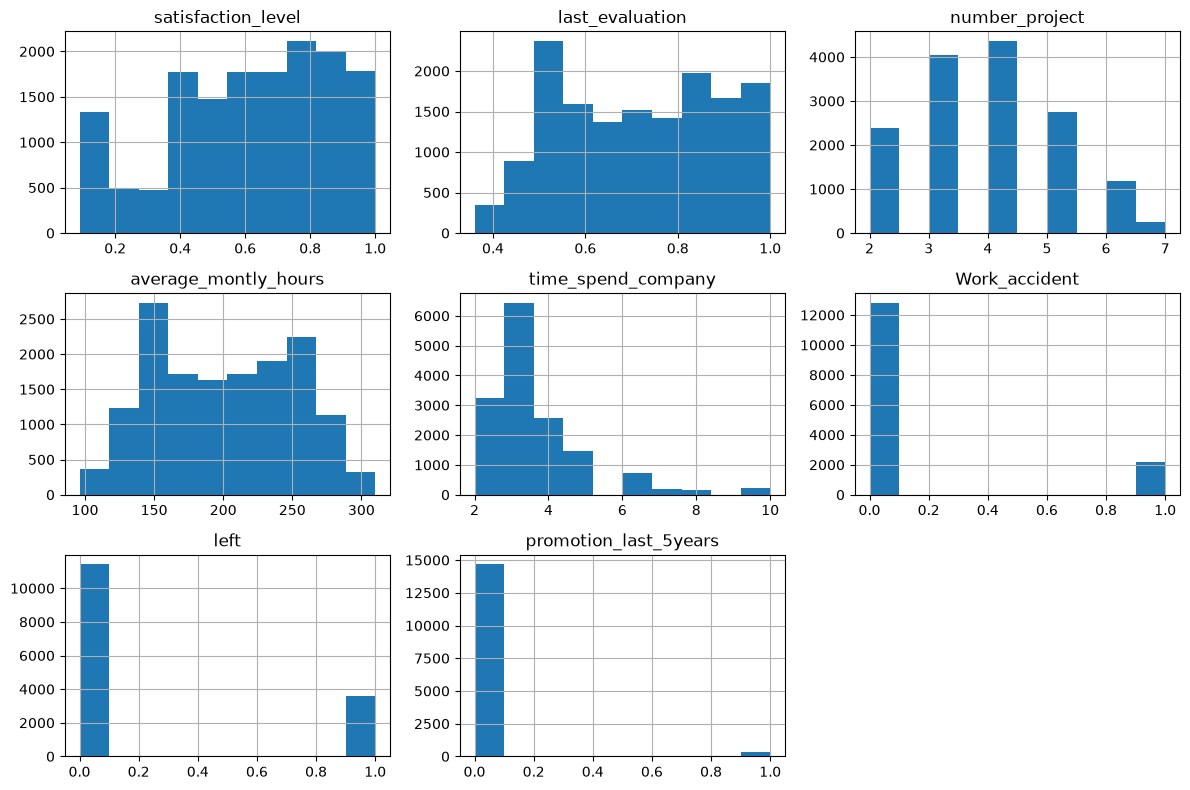

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_excel('../data/hr_employee_data.xlsx')
print(df.head())
print(df.info())
print(df.describe(include='all'))
print(df.isna().sum())
df.select_dtypes('number').hist(figsize=(12, 8))
plt.tight_layout()
plt.show()

## Uppgift 16
Modellering av diamantpriser i diamonds.csv.

In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error
from sklearn.ensemble import RandomForestRegressor

diamonds = pd.read_csv('../data/diamonds.csv').dropna()
diamonds = diamonds.drop(columns=['Unnamed: 0'])
X = diamonds.drop(columns='price')
X = pd.get_dummies(X, columns=['cut', 'color', 'clarity'], drop_first=True)
y = diamonds['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
model = RandomForestRegressor(n_estimators=50, random_state=42)
model.fit(X_train, y_train)
pred = model.predict(X_test)
print(f"Test RMSE: {root_mean_squared_error(y_test, pred):.2f}")

Test RMSE: 646.76
